In [1]:
import json
import os
from pathlib import Path

In [2]:
dataset_path = Path("G:/researchwork/dataset")

In [3]:
json_labels = [p for p in dataset_path.rglob('*.json')]

In [4]:
json_labels[0].parent.parent

WindowsPath('G:/researchwork/dataset/H_100X_C1')

Создание yolo аннотаций

In [5]:
# Функция для конвертации аннотаций
def convert_to_yolo(json_file):
    # Чтение JSON
    with open(json_file, 'r') as f:
        data = json.load(f)

    # Получить путь для сохранения YOLO аннотаций
    output_dir = json_file.parent.parent / "yolo_labels"
    output_dir.mkdir(exist_ok=True)

    # Пройти по всем аннотациям
    for annotation in data.get("annotations", []):
        # Извлечь данные аннотации
        image_id = annotation["image_id"]
        category_id = annotation["category_id"]
        bbox = annotation["bbox"]

        # Найти метаинформацию о изображении
        image_info = next((img for img in data["images"] if img["id"] == image_id), None)
        if not image_info:
            continue

        img_width, img_height = image_info["width"], image_info["height"]

        # Преобразовать bbox в формат YOLO
        x_center = (bbox[0] + bbox[2] / 2) / img_width
        y_center = (bbox[1] + bbox[3] / 2) / img_height
        width = bbox[2] / img_width
        height = bbox[3] / img_height

        # Создать строку YOLO-аннотации
        yolo_line = f"{category_id} {x_center} {y_center} {width} {height}\n"

        # Путь к YOLO-файлу
        yolo_file = output_dir / f"{image_info['file_name'].split('.')[0]}.txt"

        # Сохранить строку в файл
        with open(yolo_file, "a") as out_f:
            out_f.write(yolo_line)

In [6]:
from tqdm import tqdm

In [7]:
# Конвертировать все JSON-файлы
for json_file in tqdm(json_labels):
    convert_to_yolo(json_file)

100%|██████████| 28/28 [00:27<00:00,  1.03it/s]


Визуализируем, проверим аннотацию

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [9]:
def visualize_yolo_annotation(image_path, annotation_path):
    # Открыть изображение
    image = Image.open(image_path)
    img_width, img_height = image.size

    # Загрузить YOLO-аннотации
    with open(annotation_path, 'r') as f:
        annotations = f.readlines()

    # Создать график
    fig, ax = plt.subplots()
    ax.imshow(image)

    # Обработать каждую строку аннотации
    for annotation in annotations:
        parts = annotation.strip().split()
        class_id = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])

        # Преобразовать координаты из YOLO в пиксели
        x_center_px = x_center * img_width
        y_center_px = y_center * img_height
        width_px = width * img_width
        height_px = height * img_height

        # Вычислить координаты верхнего левого угла
        x_min = x_center_px - width_px / 2
        y_min = y_center_px - height_px / 2

        # Нарисовать прямоугольник
        rect = plt.Rectangle((x_min, y_min), width_px, height_px, 
                             linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        # Добавить текст с классом
        ax.text(x_min, y_min - 10, f"Class {class_id}", color='red', 
                fontsize=12, backgroundcolor='white')

    # Показать изображение
    plt.axis('off')
    plt.show()

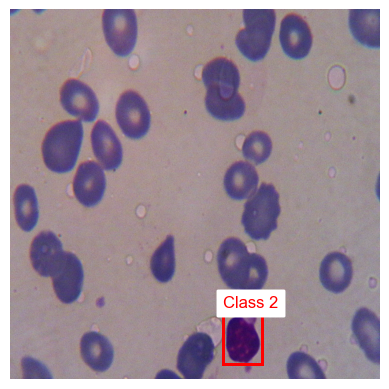

In [10]:
# Пример использования
image_path = Path("G:/researchwork/dataset/L_100X_C2/Images/test/4_8_1000_ALL.png")
annotation_path = Path("G:/researchwork/dataset/L_100X_C2/yolo_labels/4_8_1000_ALL.txt")

visualize_yolo_annotation(image_path, annotation_path)

Создание датасета в формате yolo

In [11]:
from sklearn.model_selection import train_test_split
import shutil

In [12]:
# Укажите путь к корню вашего датасета
dataset_path = Path("G:/researchwork/dataset")

In [13]:
# Соберите пути ко всем изображениям и соответствующим YOLO-аннотациям
image_paths = list(p for p in dataset_path.rglob("*.png"))
label_paths = [img.parent.parent.parent / "yolo_labels" / (img.stem + ".txt") for img in image_paths]

# Проверьте, что количество изображений и аннотаций совпадает
assert len(image_paths) == len(label_paths), "Количество изображений и аннотаций не совпадает."

In [14]:
len(label_paths)

25780

In [15]:
# Разделение на train+val и test
trainval_images, test_images, trainval_labels, test_labels = train_test_split(
    image_paths, label_paths, test_size=0.1, random_state=42
)

In [16]:
# Разделение train+val на train и val
train_images, val_images, train_labels, val_labels = train_test_split(
    trainval_images, trainval_labels, test_size=0.3, random_state=42)

In [17]:
len(train_images), len(val_images), len(test_images)

(16241, 6961, 2578)

In [18]:
# Создайте структуру папок
output_dir = dataset_path.parent / "yolo_dataset"
for split in ["train", "val", "test"]:
    (output_dir / split / "images").mkdir(parents=True, exist_ok=True)
    (output_dir / split / "labels").mkdir(parents=True, exist_ok=True)

In [33]:
# Функция для копирования файлов
def copy_files(image_files, label_files, split):
    for img_file, lbl_file in tqdm(zip(image_files, label_files)):
        try:
            shutil.copy(lbl_file, output_dir / split / "labels" / lbl_file.name)
            shutil.copy(img_file, output_dir / split / "images" / img_file.name)
        except Exception as e:
            print(e)

In [23]:
# Копирование файлов в соответствующие папки
copy_files(train_images, train_labels, "train")
copy_files(val_images, val_labels, "val")
copy_files(test_images, test_labels, "test")

print(f"Датасет преобразован и сохранён в {output_dir}.")

5140it [00:05, 998.93it/s] 

[Errno 2] No such file or directory: 'G:\\researchwork\\dataset\\H_40X_C2\\yolo_labels\\21_49_17_400_CLL.txt'


7016it [01:25, 38.04it/s] 

[Errno 2] No such file or directory: 'G:\\researchwork\\dataset\\L_40X_C1\\yolo_labels\\19_19_400_AML.txt'


8343it [02:13, 47.16it/s]

...

[Errno 2] No such file or directory: 'G:\\researchwork\\dataset\\L_40X_C1\\yolo_labels\\6_45_400_ALL.txt'


6961it [02:26, 47.56it/s]
352it [00:00, 1165.47it/s]

[Errno 2] No such file or directory: 'G:\\researchwork\\dataset\\H_40X_C2\\yolo_labels\\43_15_16_400_AML.txt'


2578it [01:12, 35.55it/s] 

Датасет преобразован и сохранён в G:\researchwork\yolo_dataset.
